# Pilot QC & data-readiness — GrENE-Net SV-GEA (sites 4 hot / 54 cold)

First gate before any modeling: confirm the 175 pilot kMate outputs are sound and
map cleanly to the longitudinal `site × generation × plot` design, so the SV Δp /
hot-vs-cold analysis (notebook 02) rests on solid data. See ../README.md.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # analysis/grenenet_gea
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import lib
plt.rcParams['figure.dpi'] = 110
CLIM = {'hot':'#d1495b', 'cold':'#3b6ea5'}

## 1. Sample map & longitudinal design

In [2]:
samples = lib.list_samples()
m = lib.sample_map(samples)
print(f'pilot samples: {len(samples)}  (mapped: {len(m)})')
print('climate:', m.climate.value_counts().to_dict())
# longitudinal structure: plots per (site, generation) — note the attrition (extinction signal)
design = m.groupby(['site','generation']).size().unstack(fill_value=0)
display(design)

pilot samples: 175  (mapped: 175)
climate: {'cold': 118, 'hot': 57}


generation,1,2,3
site,,,
4,24,22,11
54,59,35,24


## 2. Per-sample QC table
Loads the cached table (`lib.build_qc_table()` builds it from the 175 TSVs; run once).

In [3]:
qc_path = f'{lib.GEA}/pilot_qc.csv'
if os.path.exists(qc_path):
    qc = pd.read_csv(qc_path, index_col=0)
else:
    print('building QC table (reads 175 TSVs, ~15-25 min)...')
    qc = lib.build_qc_table()
print(qc.shape)
qc.head()

(175, 14)


,n_records,n_sv,n_snp,finite_af_frac,af_mean,sv_af_mean,median_n_called,frac_ncalled_lt50,eff_n_founders_mean,site,plot,generation,coverage,climate
sample,,,,,,,,,,,,,,
MLFH040120180306,10325364,2743030,7582334,1.0,0.084729,0.076694,218.0,0.005178,32.180083,4,1,1,15.312985,hot
MLFH040120180321,10325364,2743030,7582334,1.0,0.079596,0.071472,218.0,0.005178,48.401245,4,1,1,17.949709,hot
MLFH040120190208,10325364,2743030,7582334,1.0,0.088147,0.079367,218.0,0.005178,12.017620,4,1,2,16.600813,hot
MLFH040120190221,10325364,2743030,7582334,1.0,0.082567,0.074270,218.0,0.005178,39.776505,4,1,2,6.002044,hot
MLFH040120200206,10325364,2743030,7582334,1.0,0.089044,0.080058,218.0,0.005178,14.442382,4,1,3,5.276738,hot


In [4]:
# aggregate QC by climate
agg = qc.groupby('climate').agg(
    n=('n_sv','size'),
    coverage_med=('coverage','median'),
    n_sv_med=('n_sv','median'),
    finite_af_frac_min=('finite_af_frac','min'),
    sv_af_mean_med=('sv_af_mean','median'),
    eff_n_founders_med=('eff_n_founders_mean','median'),
    frac_ncalled_lt50_med=('frac_ncalled_lt50','median'),
)
display(agg)
print('\nfinite-AF fraction across all samples: min=%.4f (want ~1.0)' % qc.finite_af_frac.min())
print('n_sv consistency: std/mean = %.3f (want small — same panel)' % (qc.n_sv.std()/qc.n_sv.mean()))

,n,coverage_med,n_sv_med,finite_af_frac_min,sv_af_mean_med,eff_n_founders_med,frac_ncalled_lt50_med
climate,,,,,,,
cold,118,7.592052,2743030.0,1.0,0.071292,19.094761,0.005178
hot,57,5.425527,2743030.0,1.0,0.076912,26.250670,0.005178



finite-AF fraction across all samples: min=1.0000 (want ~1.0)
n_sv consistency: std/mean = 0.000 (want small — same panel)


## 3. QC plots

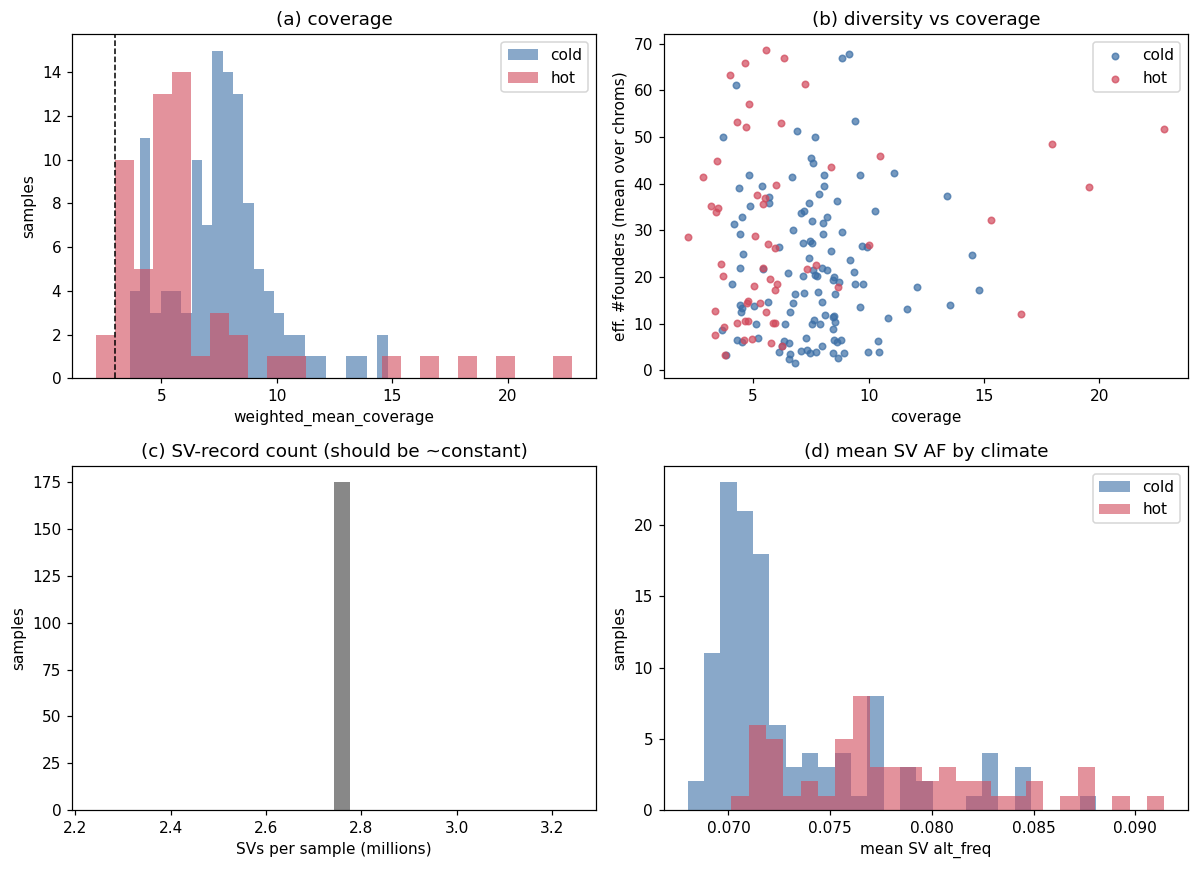

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(11, 8))

# (a) coverage distribution by climate
for c,g in qc.groupby('climate'):
    ax[0,0].hist(g.coverage, bins=25, alpha=.6, label=c, color=CLIM[c])
ax[0,0].axvline(3, ls='--', c='k', lw=1); ax[0,0].set(xlabel='weighted_mean_coverage', ylabel='samples', title='(a) coverage')
ax[0,0].legend()

# (b) effective #founders vs coverage (does low cov collapse diversity?)
for c,g in qc.groupby('climate'):
    ax[0,1].scatter(g.coverage, g.eff_n_founders_mean, s=18, alpha=.7, label=c, color=CLIM[c])
ax[0,1].set(xlabel='coverage', ylabel='eff. #founders (mean over chroms)', title='(b) diversity vs coverage')
ax[0,1].legend()

# (c) SV count per sample (panel consistency)
ax[1,0].hist(qc.n_sv/1e6, bins=30, color='#888'); ax[1,0].set(xlabel='SVs per sample (millions)', ylabel='samples', title='(c) SV-record count (should be ~constant)')

# (d) mean SV allele freq by climate — first hint of a hot/cold shift
for c,g in qc.groupby('climate'):
    ax[1,1].hist(g.sv_af_mean, bins=25, alpha=.6, label=c, color=CLIM[c])
ax[1,1].set(xlabel='mean SV alt_freq', ylabel='samples', title='(d) mean SV AF by climate'); ax[1,1].legend()

plt.tight_layout(); plt.savefig(f'{lib.GEA}/01_pilot_qc.png', dpi=130, bbox_inches='tight'); plt.show()

## 4. Coverage filter & readiness verdict

In [6]:
# how many samples survive a min-coverage filter, per (site, generation)?
for thr in [0, 3, 4, 5]:
    keep = qc[qc.coverage >= thr]
    n = keep.groupby(['site','generation']).size()
    print(f'min coverage {thr}x: {len(keep)}/{len(qc)} samples kept')
print()
# per-(site,gen) retained at the recommended 3x floor
rec = qc[qc.coverage >= 3].groupby(['site','generation']).size().unstack(fill_value=0)
print('plots retained per (site, generation) at >=3x:'); display(rec)
print('\nREADINESS: finite-AF=%.3f, SV-count CV=%.3f, all samples mapped — '
      'data is ready for SV Δp / hot-vs-cold (notebook 02).'
      % (qc.finite_af_frac.min(), qc.n_sv.std()/qc.n_sv.mean()))

min coverage 0x: 175/175 samples kept
min coverage 3x: 173/175 samples kept
min coverage 4x: 159/175 samples kept
min coverage 5x: 133/175 samples kept

plots retained per (site, generation) at >=3x:


generation,1,2,3
site,,,
4,23,21,11
54,59,35,24



READINESS: finite-AF=1.000, SV-count CV=0.000, all samples mapped — data is ready for SV Δp / hot-vs-cold (notebook 02).
